Load train and test

In [20]:
import pandas as pd
import numpy as np

BASE = "C:/Users/nikes/OneDrive/Desktop/Beginner-to-Architect/aiguard/airguard-uk/airguard-uk"

train = pd.read_csv(f"{BASE}/models/train.csv")
test  = pd.read_csv(f"{BASE}/models/test.csv")

FEATURES = ['city_code','hour','day_of_week','month','season','is_weekend',
            'NO2','PM2.5','PM10','O3','SO2','temp','humidity','wind_speed','pressure']
TARGET = 'DAQI_class'

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train class counts:\n{y_train.value_counts().sort_index()}")

X_train: (175315, 15)  |  X_test: (43800, 15)
y_train class counts:
DAQI_class
0    171893
1      3017
2       330
3        75
Name: count, dtype: int64


Apply SMOTE to training set only

In [21]:
# Check which columns still have NaN
print("NaN counts in X_train:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

# Fix — fill any remaining NaN with column median
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

print("\nNaN counts after fix:")
print(X_train.isna().sum().sum(), "remaining in X_train")
print(X_test.isna().sum().sum(), "remaining in X_test")

NaN counts in X_train:
SO2    70126
dtype: int64

NaN counts after fix:
0 remaining in X_train
0 remaining in X_test


In [22]:
from imblearn.over_sampling import SMOTE

print("Applying SMOTE to training set...")
print(f"Before: {dict(y_train.value_counts().sort_index())}")

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"After:  {dict(pd.Series(y_train_bal).value_counts().sort_index())}")
print(f"\nTraining set size: {len(X_train_bal):,} rows")
print("Test set unchanged — SMOTE never touches test data")

Applying SMOTE to training set...
Before: {0: np.int64(171893), 1: np.int64(3017), 2: np.int64(330), 3: np.int64(75)}
After:  {0: np.int64(171893), 1: np.int64(171893), 2: np.int64(171893), 3: np.int64(171893)}

Training set size: 687,572 rows
Test set unchanged — SMOTE never touches test data


Train XGBoost

In [28]:
from xgboost import XGBClassifier

print("Training XGBoost...")

model = XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\nTraining complete.")

Training XGBoost...
[0]	validation_0-mlogloss:1.29450
[50]	validation_0-mlogloss:0.13060
[100]	validation_0-mlogloss:0.02545
[150]	validation_0-mlogloss:0.01162
[200]	validation_0-mlogloss:0.00922
[250]	validation_0-mlogloss:0.00853
[300]	validation_0-mlogloss:0.00777
[350]	validation_0-mlogloss:0.00713
[400]	validation_0-mlogloss:0.00651
[450]	validation_0-mlogloss:0.00613
[500]	validation_0-mlogloss:0.00590
[550]	validation_0-mlogloss:0.00567
[600]	validation_0-mlogloss:0.00550
[650]	validation_0-mlogloss:0.00537
[700]	validation_0-mlogloss:0.00533
[750]	validation_0-mlogloss:0.00528
[800]	validation_0-mlogloss:0.00527
[850]	validation_0-mlogloss:0.00523
[900]	validation_0-mlogloss:0.00526
[950]	validation_0-mlogloss:0.00527
[999]	validation_0-mlogloss:0.00528

Training complete.


Evaluate on test set


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         Low      0.999     0.998     0.999     42524
    Moderate      0.943     0.972     0.958      1150
        High      0.936     1.000     0.967       103
   Very High      1.000     1.000     1.000        23

    accuracy                          0.998     43800
   macro avg      0.970     0.993     0.981     43800
weighted avg      0.998     0.998     0.998     43800



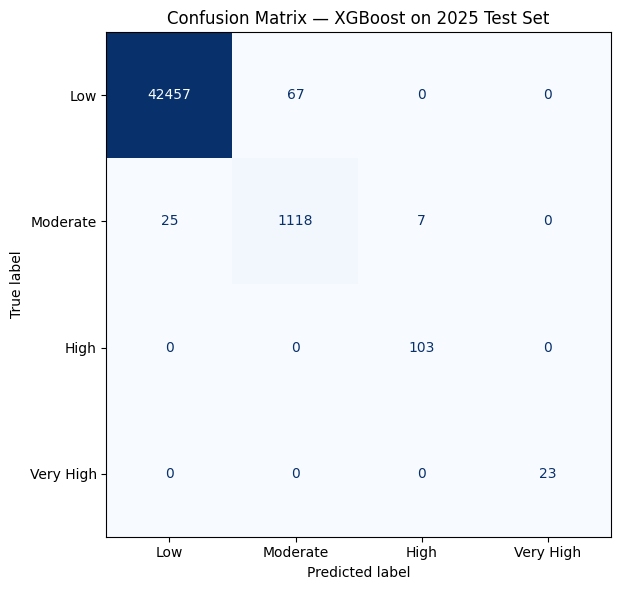

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, y_pred,
    target_names=['Low','Moderate','High','Very High'],
    digits=3
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low','Moderate','High','Very High']
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — XGBoost on 2025 Test Set')
plt.tight_layout()
plt.savefig(f"{BASE}/plots/confusion_matrix.png")
plt.show()

Feature importance

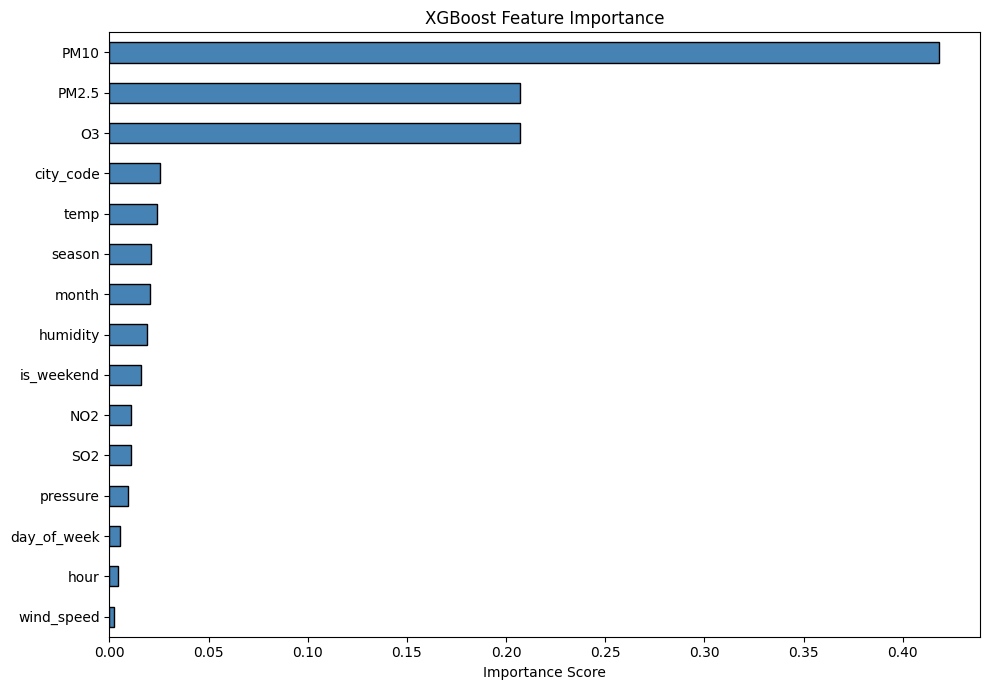


Top 5 features:
PM10         0.418039
PM2.5        0.207002
O3           0.206878
city_code    0.025456
temp         0.023915
dtype: float32


In [31]:
importances = pd.Series(model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f"{BASE}/plots/feature_importance.png")
plt.show()

print("\nTop 5 features:")
print(importances.sort_values(ascending=False).head(5))

SHAP explainability

Computing SHAP values... (takes 1-2 minutes)


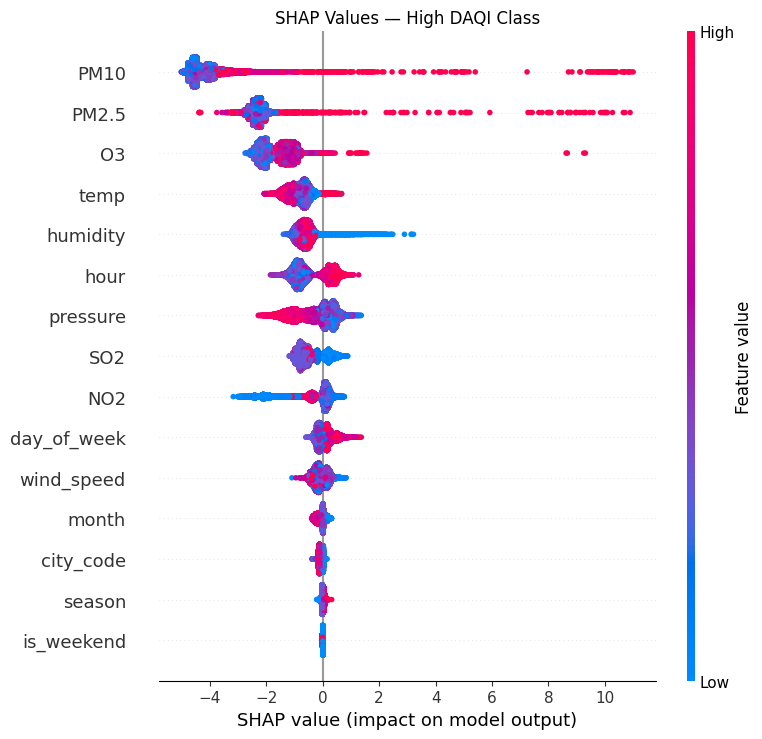

In [32]:
import shap

print("Computing SHAP values... (takes 1-2 minutes)")

explainer = shap.TreeExplainer(model)
shap_explanation = explainer(X_test)

# summary plot for High class (index 2)
shap.summary_plot(
    shap_explanation.values[:, :, 2],
    X_test,
    show=False,
    max_display=15
)
plt.title("SHAP Values — High DAQI Class")
plt.tight_layout()
plt.savefig(f"{BASE}/plots/shap_summary.png", bbox_inches='tight')
plt.show()

Save the model

In [33]:
import joblib
import os

os.makedirs(f"{BASE}/models", exist_ok=True)
joblib.dump(model, f"{BASE}/models/xgboost_model.pkl")

print(f"Model saved → models/xgboost_model.pkl")
print(f"Model size: {os.path.getsize(f'{BASE}/models/xgboost_model.pkl') / 1024:.1f} KB")

Model saved → models/xgboost_model.pkl
Model size: 6151.4 KB
